
=== Reasoning Length & Richness ===
                      model  avg_reason_length  lexical_diversity_ttr  \
0           aya-expanse-32b              27.08                  0.260   
6           llama3.3-latest              19.54                  0.257   
5           llama3.2-latest              19.43                  0.271   
1                gemma3-12b              19.33                  0.291   
2                gemma3-27b              17.85                  0.327   
4                  llama3.1              17.40                  0.290   
3                     gpt4o              15.66                  0.301   
11              qwen2.5-72b              14.34                  0.303   
7     mistral-small-3.2-24b              13.15                  0.308   
10              qwen2.5-32b              13.02                  0.332   
8   mistral-small3.1-latest              12.80                  0.295   
9               qwen2.5-14b              12.04                  0.339   

    because  

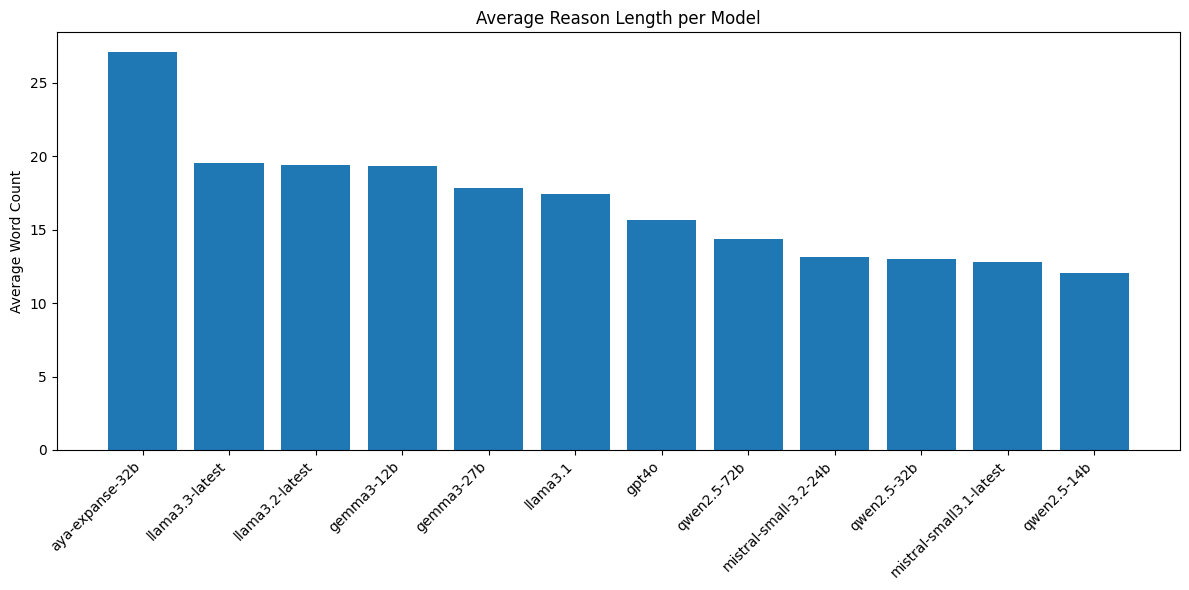

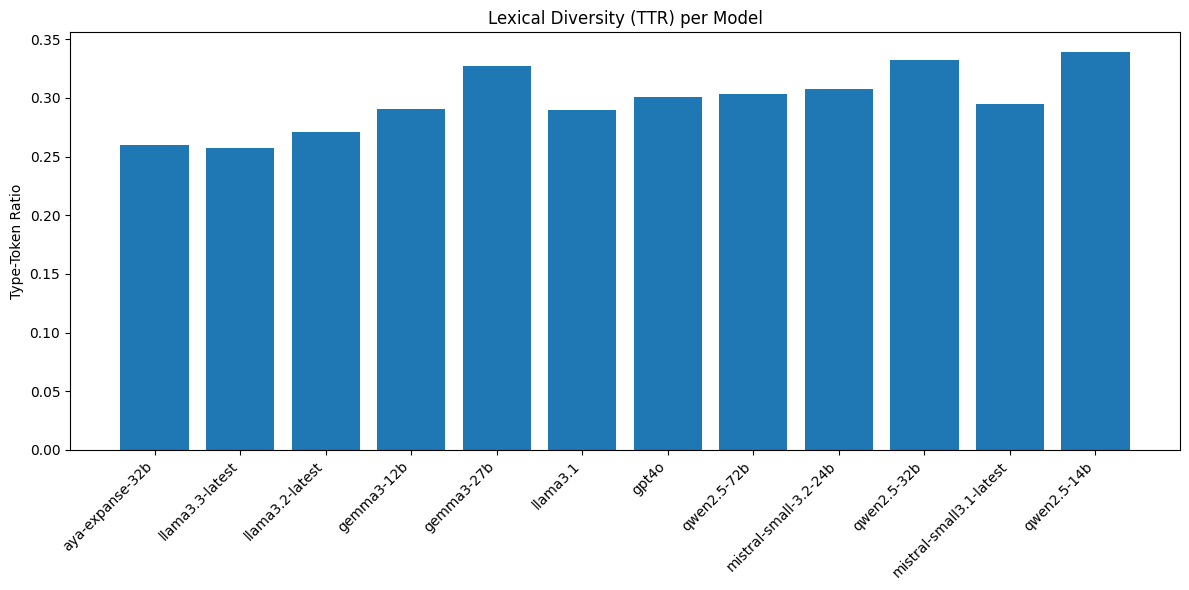

In [1]:
import os
import re
import pandas as pd
import matplotlib.pyplot as plt

# -------- Settings --------
data_path = "./"
csv_files = [
    "aya-expanse-32b_test.csv",
    "gemma3-12b_test.csv",
    "gemma3-27b_test.csv",
    "gpt4o_test.csv",
    "llama3.1_test.csv",
    "llama3.2-latest_test.csv",
    "llama3.3-latest_test.csv",
    "mistral-small-3.2-24b_test.csv",
    "mistral-small3.1-latest_test.csv",
    "qwen2.5-14b_test.csv",
    "qwen2.5-32b_test.csv",
    "qwen2.5-72b_test.csv",
]

# -------- Helpers --------
def extract_reason(ans: str) -> str:
    """Extract reasoning part of the answer"""
    if not isinstance(ans, str):
        return ""
    # Remove <think>...</think>
    ans = re.sub(r"<think>.*?</think>", "", ans, flags=re.DOTALL).strip()

    # If "Reason:" present, take after it
    if "Reason:" in ans:
        return ans.split("Reason:", 1)[1].strip()
    # If in "X - reason" format
    m = re.match(r"^\s*[ABC]\s*[-:\)]\s*(.*)", ans)
    if m:
        return m.group(1).strip()
    # Else fallback = full text
    return ans.strip()

def tokenize(text: str):
    return re.findall(r"\b\w+\b", text.lower())

discourse_markers = ["because", "therefore", "however", "but", "so", "thus"]

# -------- Collect --------
rows = []
for file in csv_files:
    path = os.path.join(data_path, file)
    if not os.path.exists(path):
        continue

    df = pd.read_csv(path)
    model = file.replace("_test.csv", "")
    if "answer" not in df.columns:
        continue

    tmp = df[["scenario_code", "answer"]].copy()
    tmp["model"] = model
    tmp["reason"] = tmp["answer"].apply(extract_reason)

    rows.append(tmp)

all_df = pd.concat(rows, ignore_index=True)

# -------- Compute metrics --------
stats = []
for model, g in all_df.groupby("model"):
    words = []
    marker_counts = {m: 0 for m in discourse_markers}
    
    for r in g["reason"].dropna():
        toks = tokenize(r)
        words.extend(toks)
        for m in discourse_markers:
            marker_counts[m] += r.lower().count(m)
    
    total_words = len(words)
    unique_words = len(set(words))
    ttr = (unique_words / total_words) if total_words > 0 else 0
    
    avg_len = g["reason"].apply(lambda x: len(tokenize(x))).mean()
    
    stats.append({
        "model": model,
        "avg_reason_length": round(avg_len, 2),
        "lexical_diversity_ttr": round(ttr, 3),
        **marker_counts
    })

stats_df = pd.DataFrame(stats).sort_values("avg_reason_length", ascending=False)
stats_df.to_csv("reasoning_richness.csv", index=False)

print("\n=== Reasoning Length & Richness ===")
print(stats_df)

# -------- Plots --------
plt.figure(figsize=(12,6))
plt.bar(stats_df["model"], stats_df["avg_reason_length"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Average Word Count")
plt.title("Average Reason Length per Model")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12,6))
plt.bar(stats_df["model"], stats_df["lexical_diversity_ttr"])
plt.xticks(rotation=45, ha="right")
plt.ylabel("Type-Token Ratio")
plt.title("Lexical Diversity (TTR) per Model")
plt.tight_layout()
plt.show()
